In [1]:
%load_ext autoreload
%autoreload 2

import sklearn
import scipy 
import numpy as np
import pandas as pd
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "0"
sys.path.append(os.path.abspath("src"))
import jdcoot
import math
from scipy.io import loadmat
from jdcoot.utils import xcolumns
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder as onehot
from jdcoot.coot import cot_numpy
from jdcoot.models.discrete_unsupervised_jdcoot import discrete_unsupervised_jdcoot
from jdcoot.models.discrete_semisupervised_jdcoot import discrete_semisupervised_jdcoot
from jdcoot.models.discrete_partial_jdcoot import discrete_partial_jdcoot
from jdcoot.models.discrete_unsupervised_coot import discrete_unsupervised_coot
from jdcoot.models.discrete_semisupervised_coot import discrete_semisupervised_coot
from jdcoot.models.discrete_partial_coot import discrete_partial_coot
from jdcoot.models.discrete_semisupervised_reference import discrete_semisupervised_reference
from jdcoot.models.discrete_partial_reference import discrete_partial_reference
from jdcoot.utils import discrete_classifier, xcolumns, discrete_accuracy
from jdcoot.utils import xcolumns, discrete_classifiers, discrete_accuracy
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut


E0000 00:00:1775487554.106430 1982608 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775487554.112279 1982608 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
S_data = pd.read_csv("data_exp.csv")
T_data = pd.read_csv("data_met.csv")
#S_data = pd.read_csv("data_omique_S.csv")
#T_data = pd.read_csv("data_omique_T.csv")

In [3]:
# renommer les colonnes
X_colsS = ['X'+str(i) for i in range(S_data.shape[1]-1)]
X_colsT = ['X'+str(i) for i in range(T_data.shape[1]-1)]

S_data.columns = X_colsS + ['Z']
T_data.columns = X_colsT + ['Z']

# convertir Z comme dans R
mapping = {
    "CIMP-low": 0,
    "CIMP-intermediate": 1,
    "CIMP-high": 2
}

S_data["Z"] = S_data["Z"].map(mapping)
T_data["Z"] = T_data["Z"].map(mapping)

S_data = S_data.dropna(subset=['Z'])
T_data = T_data.dropna(subset=['Z'])

In [4]:
# identifiants des deux datasets
source_ids = S_data["X1"]
target_ids = T_data["X1"]

# trouver les individus dans target mais pas dans source
missing_in_source = target_ids[~target_ids.isin(source_ids)]

print("Individus dans target mais pas dans source :")
print(missing_in_source)
T_data = T_data[~T_data["X1"].isin(missing_in_source)]

# vérifier
print(T_data.shape)

S_data = S_data.iloc[:, 2:]
T_data = T_data.iloc[:, 2:]

Individus dans target mais pas dans source :
3    TCGA-OR-A5J4
Name: X1, dtype: object
(78, 370368)


In [5]:
X_colsS = ['X'+str(i) for i in range(S_data.shape[1]-1)]
X_colsT = ['X'+str(i) for i in range(T_data.shape[1]-1)]
S_data.columns = X_colsS + ['Z']
T_data.columns = X_colsT + ['Z']

source = S_data
target = T_data

source = source.dropna(subset=['Z'])
target = target.dropna(subset=['Z'])
x_source = source.loc[:, xcolumns(source)].values
x_target = target.loc[:, xcolumns(target)].values
selector = VarianceThreshold(threshold=10000)
x_source_reduced = selector.fit_transform(x_source)
selector = VarianceThreshold(threshold=0.1)#0.12
x_target_reduced = selector.fit_transform(x_target)
#x_target_reduced = selector.fit_transform(x_source)
x_target_reduced.shape
scaler_s = StandardScaler()
scaler_t = StandardScaler()

x_source_scaled = scaler_s.fit_transform(x_source_reduced)
x_target_scaled = scaler_t.fit_transform(x_target_reduced)
X_df = pd.DataFrame(x_source_scaled, columns=['X'+str(i) for i in range(x_source_reduced.shape[1])])
X_df['Z'] = source['Z'].values
source = X_df
X_df = pd.DataFrame(x_target_scaled, columns=['X'+str(i) for i in range(x_target_reduced.shape[1])])
X_df['Z'] = target['Z'].values
target = X_df
source.shape,target.shape

((78, 8512), (78, 4091))

In [7]:
source.shape,target.shape

((78, 8512), (78, 4091))

In [6]:
source_levels = np.unique(source.Z)
target_levels = np.unique(source.Z)
size_target = target.Z.size

x_source = source.loc[:, xcolumns(source)].values
x_target = target.loc[:, xcolumns(target)].values

z_source = source.Z.values
z_target = target.Z.values
nClass = len(np.union1d(source_levels, target_levels))
categories = [np.arange(nClass)]

encoder = onehot(
        handle_unknown="ignore", sparse_output=False, categories=categories
    )

def one_hot(z):
        return encoder.fit_transform(z.reshape(-1, 1))

def one_cold(z):
        return encoder.inverse_transform(z).ravel()

Ts, Tv, cost = cot_numpy(
        X1=x_source,
        X2=x_target,
        niter=100,
        algo="emd",
        reg=0.01,  
        algo2="emd",
        verbose=False,
    )

z_target_pred = size_target * np.dot(Ts.T, one_hot(z_source))
perf_pure_target = discrete_accuracy(z_target, one_cold(z_target_pred))
perf_pure_target



Delta:       0.1227071 	 Loss:       1.3363783
Delta:       0.0000000 	 Loss:       1.3363783
converged at iter  1


np.float64(0.5)

In [ ]:
# Mauvaise performance, je modifie les données pour avoir au maximum des corrélations positives (en changeant le signe quand la corrélation est négative)

In [7]:
corr_matrix = np.corrcoef(
    x_source_scaled.T,
    x_target_scaled.T
)

p = x_source_scaled.shape[1]

corr_source_target = corr_matrix[:p, p:]

# meilleure correspondance target pour chaque variable source
best_target = np.argmax(np.abs(corr_source_target), axis=1)

# signe des corrélations
signs = np.sign(corr_source_target[np.arange(p), best_target])
signs = np.where(signs == 0, 1, signs)

# inversion des colonnes source si corrélation négative
x_source_scaled = x_source_scaled * signs

#selected_cols = np.where(np.abs(corr_source_target)) > threshold)[0]
#selected_cols 
#x_source_selected = x_source_reduced[:, selected_cols]

corr_final = np.corrcoef(x_source_scaled.T, x_target_scaled.T)

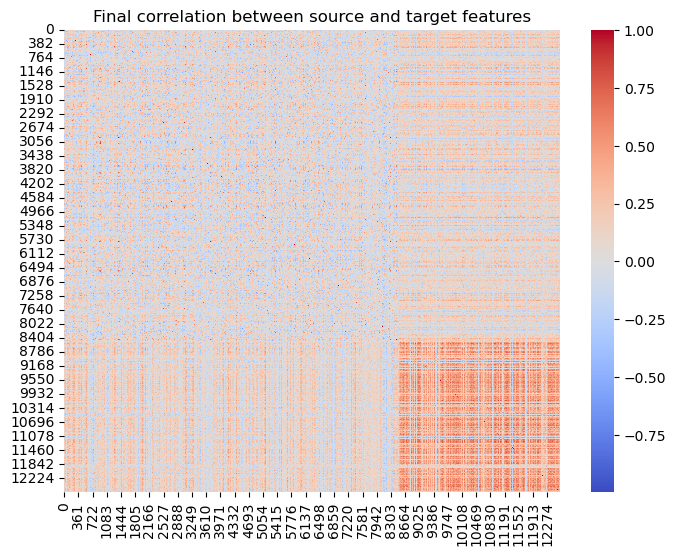

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_final, cmap="coolwarm", center=0)
plt.title("Final correlation between source and target features")
plt.show()

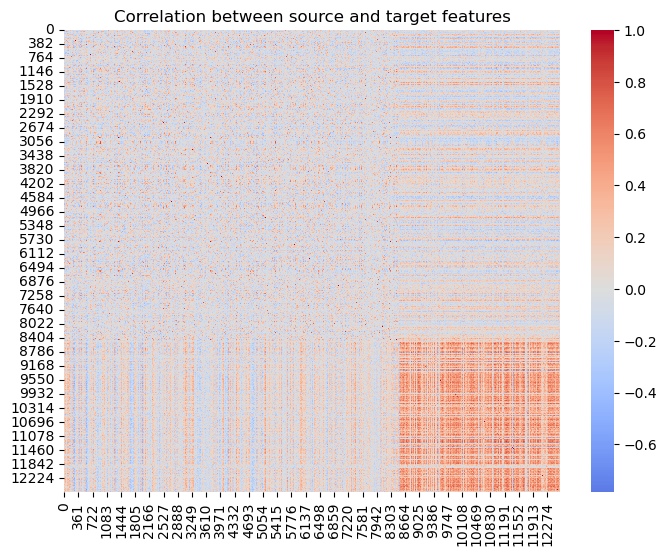

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation between source and target features")
plt.show()

In [8]:
X_df = pd.DataFrame(x_source_scaled, columns=['X'+str(i) for i in range(x_source_scaled.shape[1])])
X_df['Z'] = S_data['Z'].values
source = X_df
X_df = pd.DataFrame(x_target_scaled, columns=['X'+str(i) for i in range(x_target_scaled.shape[1])])
X_df['Z'] = T_data['Z'].values
target = X_df

x_source = source.loc[:, xcolumns(source)].values
x_target = target.loc[:, xcolumns(target)].values

z_source = source.Z.values
z_target = target.Z.values

source_levels = np.unique(source.Z)
target_levels = np.unique(target.Z)

nClass = len(np.union1d(source_levels, target_levels))
categories = [np.arange(nClass)]

Ts, Tv, cost = cot_numpy(
        X1=x_source,
        X2=x_target,
        niter=100,
        algo="emd",
        reg=0.01,  
        algo2="emd",
        verbose=False,
    )

z_target_pred = size_target * np.dot(Ts.T, one_hot(z_source))
perf_pure_target = discrete_accuracy(z_target, one_cold(z_target_pred))
perf_pure_target

Delta:       0.1227113 	 Loss:       1.2266640
Delta:       0.0000000 	 Loss:       1.2266640
converged at iter  1


NameError: name 'size_target' is not defined

In [ ]:
# je cree des echantillons independants pour le train et le test, en prenant un individu de chaque classe pour le train et le reste pour le test

In [ ]:
from sklearn.model_selection import train_test_split
X_df = pd.DataFrame(x_source_scaled, columns=['X'+str(i) for i in range(x_source_scaled.shape[1])])
X_df['Z'] = source['Z'].values
source = X_df
X_df = pd.DataFrame(x_target_scaled, columns=['X'+str(i) for i in range(x_target_scaled.shape[1])])
X_df['Z'] = target['Z'].values
target = X_df
indices = np.arange(len(source))

# split stratifié sur Z
idx_source, idx_target = train_test_split(
    indices,
    test_size=0.5,
    stratify=source['Z'],
    random_state=42
)

# séparation
source_split = source.iloc[idx_source].reset_index(drop=True)
target_split = target.iloc[idx_target].reset_index(drop=True)
source2 = source_split
target2 = target_split

source2.shape, target2.shape

((39, 8512), (39, 4091))

In [ ]:
x_source = source2.loc[:, xcolumns(source)].values
x_target = target2.loc[:, xcolumns(target)].values

z_source = source2.Z.values
z_target = target2.Z.values
nClass = len(np.union1d(source_levels, target_levels))
categories = [np.arange(nClass)]

Ts, Tv, cost = cot_numpy(
        X1=x_source,
        X2=x_target,
        niter=100,
        algo="emd",
        reg=0.01,  
        algo2="emd",
        verbose=False,
    )

z_target_pred = size_target * np.dot(Ts.T, one_hot(z_source))
perf_pure_target = discrete_accuracy(z_target, one_cold(z_target_pred))
perf_pure_target

Delta:       0.1682594 	 Loss:       1.0708975
Delta:       0.0000000 	 Loss:       1.0708975
converged at iter  1


np.float64(0.717948717948718)

In [11]:
algo = "emd"
reg = 0.1
S=source2
T=target2
S_test = source2
T_test = target2
pure_source, pure_target, test_source, test_target =  discrete_unsupervised_coot(S, T, S_test, T_test,algo=algo,reg=reg,batch_size=20)
test_target

Delta:       0.1682594 	 Loss:       1.0708975
Delta:       0.0000000 	 Loss:       1.0708975
converged at iter  1


I0000 00:00:1774606897.877196  982920 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31129 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1774606898.927999 1004704 service.cc:148] XLA service 0x742f69305120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774606898.928038 1004704 service.cc:156]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
I0000 00:00:1774606898.946552 1004704 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774606899.037627 1004704 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


np.float64(0.717948717948718)

In [36]:
alpha=1.2
algo = "emd"
reg = 0.1
alpha = 1
pure_source, pure_target, test_source, test_target = discrete_unsupervised_jdcoot(S, T, S_test, T_test, algo=algo, reg=reg,batch_size=20, alpha=alpha)
test_target

#JDCOOT = COOT car il converge à une itération !!

Delta: 0.0 	  Loss: 1.0708974541326224 	 Accuracy: 0.717948717948718
converged at iter  0


np.float64(0.717948717948718)

In [8]:
from jdcoot.models.discrete_semisupervised_jdcoot import discrete_semisupervised_jdcoot
from jdcoot.models.discrete_partial_jdcoot import discrete_partial_jdcoot
from jdcoot.models.discrete_unsupervised_coot import discrete_unsupervised_coot
from jdcoot.models.discrete_semisupervised_coot import discrete_semisupervised_coot
from jdcoot.models.discrete_partial_coot import discrete_partial_coot
from jdcoot.models.discrete_partial_coot2 import discrete_partial_coot2
from jdcoot.models.discrete_semisupervised_reference import discrete_semisupervised_reference
from jdcoot.models.discrete_partial_reference import discrete_partial_reference

In [13]:
S=source2
T=target2
S_test = source2
T_test = target2
l_source_train = np.where(np.isin(S['Z'], [0]))[0]
l_source_test  = np.where(np.isin(S['Z'], [1,2]))[0]

# ===== TARGET =====
l_target_train = np.where(np.isin(T['Z'], [1,2]))[0]
l_target_test  = np.where(np.isin(T['Z'], [0]))[0]

In [17]:
pure_source, pure_target, test_source, test_target = discrete_partial_coot(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test,algo="emd",reg=0.1,batch_size=len(S)            
            )
test_target

/home/vgares/mambaforge/envs/jdcoot/lib/python3.12/site-packages/tensorflow/python/util/dispatch.py:1260: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return dispatch_target(*args, **kwargs)


 Accuracy: 0.0
Delta:       0.1682594 	 Loss:       1.0708975
Delta:       0.0000000 	 Loss:       1.0708975
converged at iter  1
Ts sum: 0.9999999999999999
Ts max: 0.02564102564102564
Ts min: 0.0


np.float64(1.0)

In [19]:
test_source

np.float64(0.8717948717948718)

In [14]:
pure_source, pure_target, test_source, test_target = discrete_partial_coot2(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test,algo="emd",reg=0.1,batch_size=len(S)            
            )
test_target

I0000 00:00:1774981372.718191 2846627 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31129 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
/home/vgares/mambaforge/envs/jdcoot/lib/python3.12/site-packages/tensorflow/python/util/dispatch.py:1260: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return dispatch_target(*args, **kwargs)
I0000 00:00:1774981374.789620 2891439 service.cc:148] XLA service 0x7ede8580a9f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774981374.789678 2891439 service.cc:156]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
I0000 00:00:1774981374.826676 2891439 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:17

Delta:       0.1535481 	 Loss:       1.1928227
Delta:       0.0320105 	 Loss:       1.1836182
Delta:       0.0109966 	 Loss:       1.1814333
Delta:       0.0000000 	 Loss:       1.1814333
converged at iter  3


/home/vgares/mambaforge/envs/jdcoot/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:630: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/home/vgares/mambaforge/envs/jdcoot/lib/python3.12/site-packages/ot/backend.py:1197: RuntimeWarning: invalid value encountered in dot
  return np.dot(a, b)
/home/vgares/mambaforge/envs/jdcoot/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)


Delta:       0.0408795 	 Loss:       2.0881444
Delta:       0.0148620 	 Loss:       2.0813214
Delta:       0.0128606 	 Loss:       2.0787133
Delta:       0.0100995 	 Loss:       2.0773432
Delta:       0.0081997 	 Loss:       2.0768340
Delta:       0.0072254 	 Loss:       2.0765803
Delta:       0.0064724 	 Loss:       2.0764212
Delta:       0.0059467 	 Loss:       2.0763113
Delta:       0.0057604 	 Loss:       2.0762166
Delta:       0.0054838 	 Loss:       2.0761313
Delta:       0.0050442 	 Loss:       2.0760605
Delta:       0.0047133 	 Loss:       2.0760059
Delta:       0.0044733 	 Loss:       2.0759575
Delta:       0.0043151 	 Loss:       2.0759171
Delta:       0.0039252 	 Loss:       2.0758804
Delta:       0.0038479 	 Loss:       2.0758516
Delta:       0.0037693 	 Loss:       2.0758249
Delta:       0.0036892 	 Loss:       2.0758024
Delta:       0.0035842 	 Loss:       2.0757826
Delta:       0.0032410 	 Loss:       2.0757647
Delta:       0.0030715 	 Loss:       2.0757496
Delta:       

np.float64(1.0)

In [20]:
pure_source, pure_target, test_source, test_target = discrete_partial_reference(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test
            )
test_target

/home/vgares/mambaforge/envs/jdcoot/lib/python3.12/site-packages/tensorflow/python/util/dispatch.py:1260: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return dispatch_target(*args, **kwargs)


np.float64(0.5897435897435898)

In [21]:
test_source

np.float64(0.41025641025641024)

In [24]:
prop_source=0.5
prop_target=0.1
n_target = len(T.Z)
n_source = len(S.Z)
l_source_train, l_source_test = train_test_split(
        np.arange(n_source),
        train_size=prop_source
    )

l_target_train, l_target_test = train_test_split(
        np.arange(n_target),
        train_size=prop_target
    )

In [35]:
l_target_train

array([16, 17,  6])

In [25]:
pure_source, pure_target, test_source, test_target = discrete_partial_coot(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test,algo="emd",reg=0.1,batch_size=len(S)            
            )
test_target

 Accuracy: 0.6666666666666666
Delta:       0.1682679 	 Loss:       1.0744151
Delta:       0.0000000 	 Loss:       1.0744151
converged at iter  1
Ts sum: 0.9999999999999999
Ts max: 0.02564102564102564
Ts min: 0.0


np.float64(0.5897435897435898)

In [26]:
test_source

np.float64(0.8205128205128205)

In [27]:
pure_source, pure_target, test_source, test_target = discrete_partial_reference(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test
            )
test_target

np.float64(0.6923076923076923)

In [28]:
test_source

np.float64(0.8205128205128205)

In [29]:

# SOURCE
l_source_train = []
for z in np.unique(S['Z']):
    idx = np.where(S['Z'] == z)[0]
    chosen = np.random.choice(idx, size=1, replace=False)
    l_source_train.extend(chosen)

l_source_train = np.array(l_source_train)

# le reste en test
l_source_test = np.setdiff1d(np.arange(len(S['Z'])), l_source_train)


# TARGET
l_target_train = []
for z in np.unique(T['Z']):
    idx = np.where(T['Z'] == z)[0]
    chosen = np.random.choice(idx, size=1, replace=False)
    l_target_train.extend(chosen)

l_target_train = np.array(l_target_train)

l_target_test = np.setdiff1d(np.arange(len(T['Z'])), l_target_train)

In [30]:
pure_source, pure_target, test_source, test_target = discrete_partial_coot(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test,algo="emd",reg=0.1,batch_size=len(S)            
            )
test_target

 Accuracy: 0.6666666666666666
Delta:       0.1682593 	 Loss:       1.0745428
Delta:       0.0000000 	 Loss:       1.0745428
converged at iter  1
Ts sum: 0.9999999999999999
Ts max: 0.02564102564102564
Ts min: 0.0


np.float64(0.38461538461538464)

In [32]:
pure_source, pure_target, test_source, test_target = discrete_partial_coot2(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test,algo="emd",reg=0.1,batch_size=len(S)            
            )
test_target

Delta:       0.1409057 	 Loss:       1.3136899
Delta:       0.0000000 	 Loss:       1.3136899
converged at iter  1
Delta:       0.0495558 	 Loss:       1.7689483
Delta:       0.0285344 	 Loss:       1.7178485
Delta:       0.0195554 	 Loss:       1.6984084
Delta:       0.0161075 	 Loss:       1.6891520
Delta:       0.0125388 	 Loss:       1.6840297
Delta:       0.0089801 	 Loss:       1.6814564
Delta:       0.0064973 	 Loss:       1.6804355
Delta:       0.0050877 	 Loss:       1.6799712
Delta:       0.0041968 	 Loss:       1.6797458
Delta:       0.0039668 	 Loss:       1.6796057
Delta:       0.0036344 	 Loss:       1.6795190
Delta:       0.0030716 	 Loss:       1.6795072
Delta:       0.0028305 	 Loss:       1.6794748
Delta:       0.0025120 	 Loss:       1.6794695
Delta:       0.0022517 	 Loss:       1.6794606
Delta:       0.0018588 	 Loss:       1.6794348
Delta:       0.0016912 	 Loss:       1.6794116
Delta:       0.0016229 	 Loss:       1.6793940
Delta:       0.0016858 	 Loss:       1.

KeyboardInterrupt: 

In [33]:
pure_source, pure_target, test_source, test_target = discrete_partial_reference(
                S, T, S_test, T_test,l_source_train, l_source_test,l_target_train, l_target_test
            )
test_target

np.float64(0.6923076923076923)

In [35]:
perf_source_all = []
perf_target_all = []
n_reps = 5 
for rep in range(n_reps):

    print(f"\n=== Répétition {rep+1} ===")

    # ==========================
    # Split aléatoire individus
    # ==========================
    idx_source, idx_target = train_test_split(
        indices,
        test_size=0.5,
        stratify=source['Z'],
        random_state=rep
    )

    source2 = source.iloc[idx_source].reset_index(drop=True)
    target2 = target.iloc[idx_target].reset_index(drop=True)

    loo = LeaveOneOut()

    perf_source_list = []
    perf_target_list = []

    # ==========================
    # LOO interne
    # ==========================
    for train_idx, test_idx in loo.split(source2):

        # même split pour source et target (comme ton 1er code)
        S = source2.iloc[train_idx].reset_index(drop=True)
        S_test = source2.iloc[test_idx].reset_index(drop=True)

        T = target2.iloc[train_idx].reset_index(drop=True)
        T_test = target2.iloc[test_idx].reset_index(drop=True)

        # ==========================
        # Encodage
        # ==========================
        source_levels = np.sort(np.unique(S.Z))
        target_levels = np.sort(np.unique(T.Z))

        nClass = len(np.union1d(source_levels, target_levels))
        categories = [np.arange(nClass)]

        enc = onehot(handle_unknown="ignore", sparse_output=False, categories=categories)

        # train
        x_source_train = S.loc[:, xcolumns(S)].values
        z_source_train = enc.fit_transform(S.Z.values[:, np.newaxis])

        x_target_train = T.loc[:, xcolumns(T)].values
        z_target_train = enc.fit_transform(T.Z.values[:, np.newaxis])

        # test
        x_source_test = S_test.loc[:, xcolumns(S_test)].values
        z_source_test = S_test.Z.values

        x_target_test = T_test.loc[:, xcolumns(T_test)].values
        z_target_test = T_test.Z.values

        # ==========================
        # Modèles
        # ==========================
        clf_source, clf_target = discrete_classifiers(S, T, "relu", "softmax")

        clf_target.fit(
            x_target_train, z_target_train,
            batch_size=len(x_target_train), epochs=10, verbose=0, shuffle=False
        )

        clf_source.fit(
            x_source_train, z_source_train,
            batch_size=len(x_source_train), epochs=10, verbose=0, shuffle=False
        )

        # ==========================
        # Prédictions
        # ==========================
        z_target_pred = enc.inverse_transform(
            clf_target.predict(x_target_test, verbose=0)
        ).ravel()

        z_source_pred = enc.inverse_transform(
            clf_source.predict(x_source_test, verbose=0)
        ).ravel()

        # ==========================
        # Scores
        # ==========================
        perf_source_list.append(discrete_accuracy(z_source_pred, z_source_test))
        perf_target_list.append(discrete_accuracy(z_target_pred, z_target_test))

    # ==========================
    # Moyenne par répétition
    # ==========================
    perf_source_all.append(np.mean(perf_source_list))
    perf_target_all.append(np.mean(perf_target_list))


# ==========================
# Résultat final
# ==========================
print("Source accuracy:", np.mean(perf_source_all))
print("Target accuracy:", np.mean(perf_target_all))


=== Répétition 1 ===

=== Répétition 2 ===

=== Répétition 3 ===

=== Répétition 4 ===

=== Répétition 5 ===
Source accuracy: 0.6512820512820513
Target accuracy: 0.7999999999999999


In [11]:
import tensorflow as tf
tf.keras.backend.clear_session()
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [12]:
alpha_values = np.linspace(0, 1, 11)
algo = "emd"
reg = 0.1
n_reps = 5  # nombre de répétitions
results_all = []
indices = np.arange(len(source))
best_alpha_overall = None
best_score_overall = -np.inf

for rep in range(n_reps):
    print(f"\n=== Répétition {rep+1} ===")

    # ==========================
    # Split aléatoire individus
    # ==========================
    idx_source, idx_target = train_test_split(
        indices,
        test_size=0.5,
        stratify=source['Z'],
        random_state=rep
    )

    source2 = source.iloc[idx_source].reset_index(drop=True)
    target2 = target.iloc[idx_target].reset_index(drop=True)

    loo = LeaveOneOut()
    results_rep = []

    # ==========================
    # LOO interne
    # ==========================
    for train_idx, test_idx in loo.split(source2):
        S_train = source2.iloc[train_idx].reset_index(drop=True)
        S_test  = source2.iloc[test_idx].reset_index(drop=True)

        T_train = target2.iloc[train_idx].reset_index(drop=True)
        T_test  = target2.iloc[test_idx].reset_index(drop=True)

        for alpha in alpha_values:

            # ==========================
            # Appel fonction JDCOOT non supervisé
            # ==========================
            pure_source, pure_target, test_source, test_target = \
                discrete_unsupervised_jdcoot(
                    S_train,
                    T_train,
                    S_test,
                    T_test,
                    algo=algo,
                    reg=reg,
                    batch_size=len(S_train),
                    alpha=alpha
                )

            results_rep.append({
                "rep": rep+1,
                "alpha": alpha,
                "loo_score": test_target
            })

    # ==========================
    # Sauvegarde résultats par répétition
    # ==========================
    df_rep = pd.DataFrame(results_rep)
    results_all.append(df_rep)

    # ==========================
    # Meilleur alpha de cette rép
    # ==========================
    mean_scores = df_rep.groupby("alpha")["loo_score"].mean()
    best_alpha_rep = mean_scores.idxmax()
    best_score_rep = mean_scores.max()

    print(f"Best alpha (rep {rep+1}): {best_alpha_rep}")
    print(f"Best LOO score (rep {rep+1}): {best_score_rep}")

    if best_score_rep > best_score_overall:
        best_score_overall = best_score_rep
        best_alpha_overall = best_alpha_rep

# ==========================
# Résultats globaux
# ==========================
df_results_all = pd.concat(results_all, ignore_index=True)
df_results_all.to_excel("results_loo_all_reps.xlsx", index=False)

print("\n=== Résultat global ===")
print("Best alpha overall:", best_alpha_overall)
print("Best LOO score overall:", best_score_overall)

df_summary = df_results_all.groupby("alpha")["loo_score"].mean().reset_index()
df_summary.to_excel("results_loo_mean_alpha.xlsx", index=False)


=== Répétition 1 ===


I0000 00:00:1775251841.773514 1831113 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31129 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1775251867.732134 1839581 service.cc:148] XLA service 0x758157ffdec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775251867.732194 1839581 service.cc:156]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
I0000 00:00:1775251867.789372 1839581 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775251868.027555 1839581 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0 	  Loss: 1.074643843624898 	 Accuracy: 0.7105263157894737
converged at iter  0
Delta: 0.0

In [15]:
df_summary

,alpha,loo_score
0,0.0,0.733333
1,0.1,0.702564
2,0.2,0.743590
3,0.3,0.712821
4,0.4,0.743590
5,0.5,0.733333
6,0.6,0.743590
7,0.7,0.712821
8,0.8,0.728205
9,0.9,0.728205


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, LeaveOneOut

X_df = pd.DataFrame(x_source_scaled, columns=['X'+str(i) for i in range(x_source_scaled.shape[1])])
X_df['Z'] = source['Z'].values
target = X_df
X_df = pd.DataFrame(x_target_scaled, columns=['X'+str(i) for i in range(x_target_scaled.shape[1])])
X_df['Z'] = target['Z'].values
source = X_df
algo = "emd"
reg = 0.1
alpha = 0.2

n_reps = 5  # nombre de répétitions Monte Carlo
results = []

indices = np.arange(len(source))

for rep in range(n_reps):

    print(f"\n=== Répétition {rep+1} ===")

    # ==========================
    # Split aléatoire individus
    # ==========================
    idx_source, idx_target = train_test_split(
        indices,
        test_size=0.5,
        stratify=source['Z'],
        random_state=rep  # change à chaque répétition
    )

    source2 = source.iloc[idx_source].reset_index(drop=True)
    target2 = target.iloc[idx_target].reset_index(drop=True)

    loo = LeaveOneOut()

    scores_coot = []
    scores_jdcoot = []

    # ==========================
    # LOO interne
    # ==========================
    for train_idx, test_idx in loo.split(source2):

        S = target2.iloc[train_idx].reset_index(drop=True)
        S_test = target2.iloc[test_idx].reset_index(drop=True)

        T = source2.iloc[train_idx].reset_index(drop=True)
        T_test = source2.iloc[test_idx].reset_index(drop=True)

        # COOT
        _, _, _, test_target = discrete_unsupervised_coot(
            S, T, S_test, T_test,
            algo=algo,
            reg=reg,
            batch_size=len(S)
        )
        scores_coot.append(test_target)

        # JDCOOT
        _, _, _, test_target = discrete_unsupervised_jdcoot(
            S, T, S_test, T_test,
            algo=algo,
            reg=reg,
            batch_size=len(S),
            alpha=alpha
        )
        scores_jdcoot.append(test_target)

    # ==========================
    # Moyenne sur LOO
    # ==========================
    results.append({
        "rep": rep,
        "recoding": "coot",
        "mean_score": np.mean(scores_coot)
    })

    results.append({
        "rep": rep,
        "recoding": "jdcoot",
        "mean_score": np.mean(scores_jdcoot)
    })

df_results = pd.DataFrame(results)

df_summary = (
    df_results
    .groupby(["recoding"])
    .agg(mean_score=("mean_score", "mean"),
         std_score=("mean_score", "std"))
    .reset_index()
)

print(df_summary)

df_summary.to_excel("results_loo_mean.xlsx", index=False)


=== Répétition 1 ===


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, LeaveOneOut

X_df = pd.DataFrame(x_source_scaled, columns=['X'+str(i) for i in range(x_source_scaled.shape[1])])
X_df['Z'] = source['Z'].values
source = X_df

X_df = pd.DataFrame(x_target_scaled, columns=['X'+str(i) for i in range(x_target_scaled.shape[1])])
X_df['Z'] = target['Z'].values
target = X_df

algo = "emd"
reg = 0.1
alpha = 0.2
n_reps = 5  # nombre de répétitions Monte Carlo

results = []
indices = np.arange(len(source))

for rep in range(n_reps):
    print(f"\n=== Répétition {rep+1} ===")

    # ── Split aléatoire individus ──────────────────────────────────
    idx_source, idx_target = train_test_split(
        indices,
        test_size=0.5,
        stratify=source['Z'],
        random_state=rep
    )
    source2 = source.iloc[idx_source].reset_index(drop=True)
    target2 = target.iloc[idx_target].reset_index(drop=True)

    loo = LeaveOneOut()
    scores_coot_source   = []
    scores_coot_target   = []
    scores_jdcoot_source = []
    scores_jdcoot_target = []
    scores_pure_source   = []
    scores_pure_target   = []

    # ── LOO interne ───────────────────────────────────────────────
    for train_idx, test_idx in loo.split(source2):
        S      = target2.iloc[train_idx].reset_index(drop=True)
        S_test = target2.iloc[test_idx].reset_index(drop=True)
        T      = source2.iloc[train_idx].reset_index(drop=True)
        T_test = source2.iloc[test_idx].reset_index(drop=True)

        l_source_train = np.where(np.isin(S['Z'], [0]))[0]
        l_source_test  = np.where(np.isin(S['Z'], [1, 2]))[0]
        l_target_train = np.where(np.isin(T['Z'], [1, 2]))[0]
        l_target_test  = np.where(np.isin(T['Z'], [0]))[0]

        # COOT
        _, _, test_source, test_target = discrete_partial_coot2(
            S, T, S_test, T_test,
            l_source_train, l_source_test,
            l_target_train, l_target_test,
            algo=algo, reg=reg, batch_size=len(S)
        )
        scores_coot_source.append(test_source)
        scores_coot_target.append(test_target)

        # JDCOOT
        _, _, test_source, test_target = ddiscrete_partial_jdcoot2(
            S, T, S_test, T_test,
            l_source_train, l_source_test,
            l_target_train, l_target_test,
            algo=algo, reg=reg, batch_size=len(S), alpha=alpha
        )
        scores_jdcoot_source.append(test_source)
        scores_jdcoot_target.append(test_target)

        # Reference
        pure_source, pure_target, test_source, test_target = discrete_partial_reference(
            S, T, S_test, T_test,
            l_source_train, l_source_test,
            l_target_train, l_target_test
        )
        scores_pure_source.append(test_source)
        scores_pure_target.append(test_target)

    # ── Moyenne sur LOO ───────────────────────────────────────────
    results.append({"rep": rep, "recoding": "coot",        "source": np.mean(scores_coot_source),   "target": np.mean(scores_coot_target)})
    results.append({"rep": rep, "recoding": "jdcoot",      "source": np.mean(scores_jdcoot_source), "target": np.mean(scores_jdcoot_target)})
    results.append({"rep": rep, "recoding": "reference",   "source": np.mean(scores_pure_source),   "target": np.mean(scores_pure_target)})

df_results = pd.DataFrame(results)

# FIX: utiliser "mean_score" (pas "score")
df_summary = (
    df_results
    .groupby("recoding")
    .agg(
        mean_source=("source", "mean"),
        std_source=("source", "std"),
        mean_target=("target", "mean"),
        std_target=("target", "std")
    )
    .reset_index()
)

print(df_summary)
df_summary.to_excel("results_loo_mean.xlsx", index=False)